<a href="https://colab.research.google.com/github/gaga0321/scRNA-aging-analysis/blob/main/scRNA%20aging%20analysis%20limb%20muscle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install scanpy
import scanpy as sc
adata_aging = sc.read_h5ad("tabula-muris-senis-facs-processed-official-annotations-Limb_Muscle.h5ad")
print(list(adata_aging.obs.columns))

['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden']


/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


Ages in this cohort: ['18m', '24m', '3m']

Top 5 cell types found in this tissue:
cell_ontology_class
skeletal muscle satellite cell    1833
mesenchymal stem cell              935
endothelial cell                   453
macrophage                         311
B cell                             187
Name: count, dtype: int64


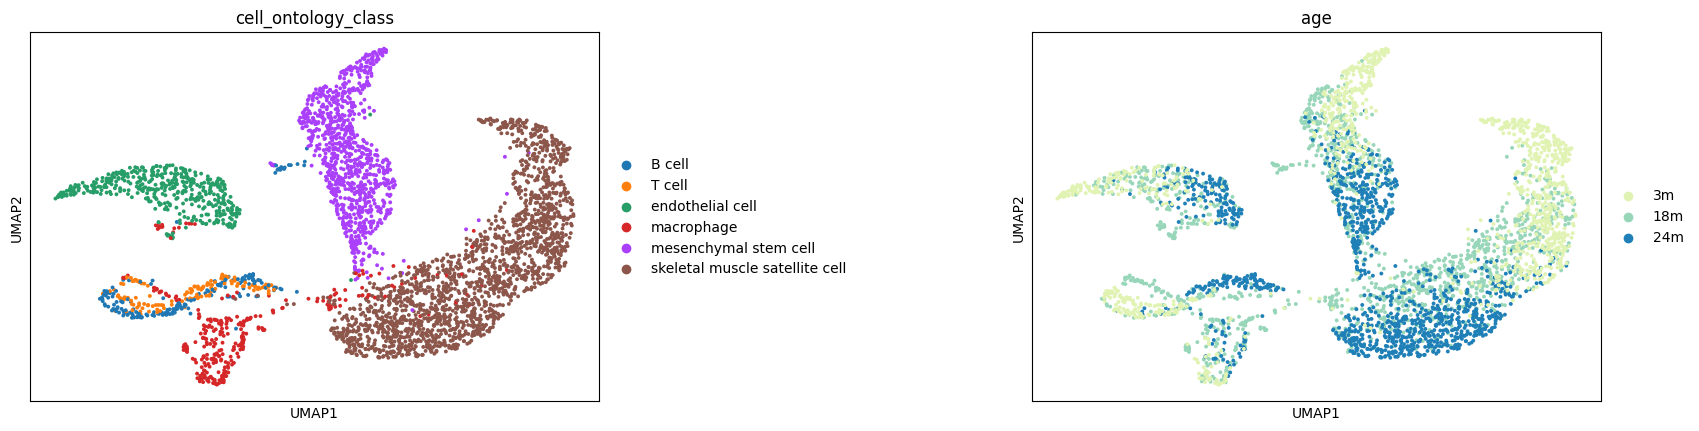

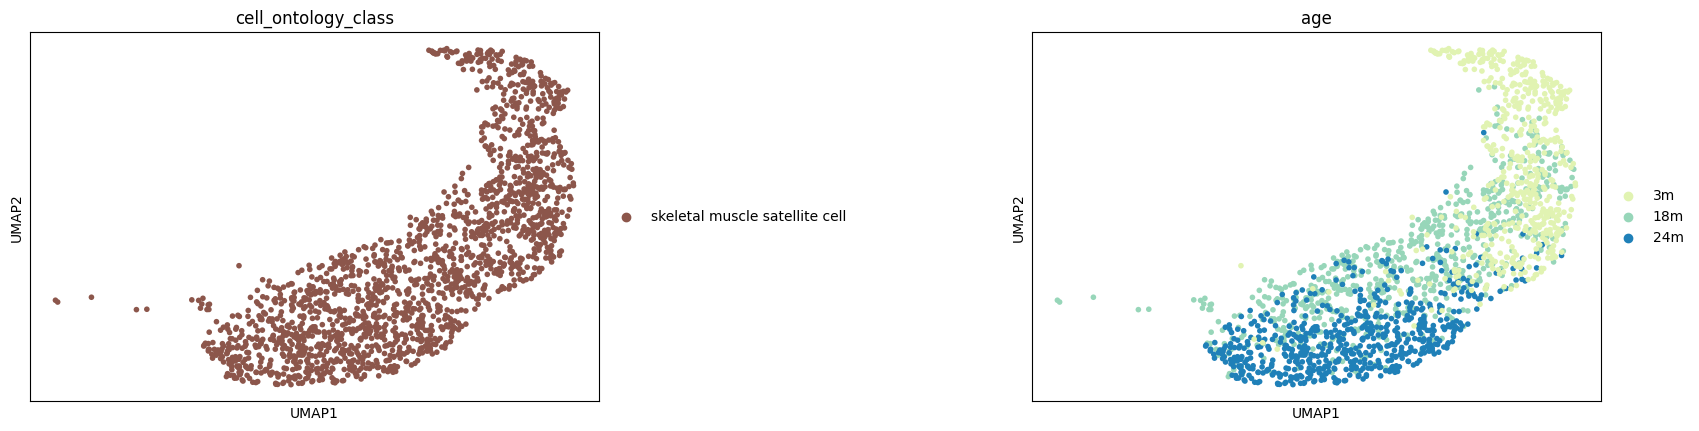

In [5]:
print("Ages in this cohort:", adata_aging.obs['age'].unique().tolist())
print("\nTop 5 cell types found in this tissue:")
print(adata_aging.obs['cell_ontology_class'].value_counts().head(5))
sc.pl.umap(adata_aging, color=['cell_ontology_class', 'age'], wspace=0.6)
Skeletal_Muscle_Satellite_Cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'skeletal muscle satellite cell'].copy()
sc.pl.umap(Skeletal_Muscle_Satellite_Cells, color=['cell_ontology_class', 'age'], wspace=0.6)

Top Upregulated Skeletal Muscle Satellite Cell Drivers (Ranked by Fold Change):
            18m_n     18m_l         18m_p
0           Prtn3  8.453140  2.679144e-09
1             Mpo  7.711149  1.467758e-13
2           Cd177  6.685533  4.131758e-08
3          Chi3l3  6.200183  2.363277e-11
4             Ltf  5.859245  1.276875e-10
5            Camp  5.848302  1.050515e-12
6            Ncf1  5.835235  3.768429e-08
7          Ifitm6  5.787142  6.732094e-06
8   1100001G20Rik  5.694058  6.906010e-06
9            Lrg1  5.681926  1.941692e-12
10        Pglyrp1  5.564820  1.080037e-20
11             Hp  5.519469  5.692812e-15
12           Nkg7  5.495562  1.362504e-08
13          Sfpi1  5.355852  2.315227e-17
14           Lcn2  5.269320  5.304190e-21
15          Plvap  5.125739  1.302157e-08
16            Ngp  5.041819  4.525281e-17
17         S100a9  4.943212  5.641388e-25
18         S100a8  4.900589  2.403599e-32
19          Plac8  4.891304  3.037271e-13


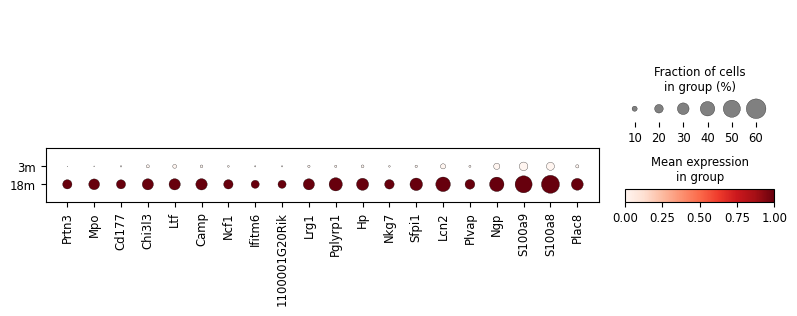

Top Downregulated Skeletal Muscle Satellite Cell Targets (Ranked by Fold Change):
     18m_n     18m_l         18m_p
0    Krt17 -9.399261  3.147346e-06
1    Krt14 -7.432052  4.499850e-24
2   P2ry12 -5.958116  3.033098e-19
3     Krt5 -5.632739  1.970922e-11
4    Ddx3y -3.806955  1.710204e-17
5   Spred1 -3.434042  9.282441e-22
6    Krt15 -3.348260  2.495828e-11
7    Lars2 -3.238705  5.950975e-28
8     Ror1 -3.081654  3.177831e-17
9     Ipo7 -3.006868  1.046067e-14
10   Cdk17 -2.953277  1.425725e-09
11  Mir703 -2.918441  4.103724e-28
12   Stt3b -2.884755  8.581307e-10
13   Hif1a -2.849709  7.734506e-18
14   Loxl2 -2.715549  2.047246e-13
15  Mir568 -2.642931  6.690358e-08
16   Tnpo1 -2.638454  3.671991e-10
17    Cbfb -2.632593  5.839255e-12
18    Copa -2.621631  5.548889e-20
19  Spire1 -2.589890  5.070859e-14


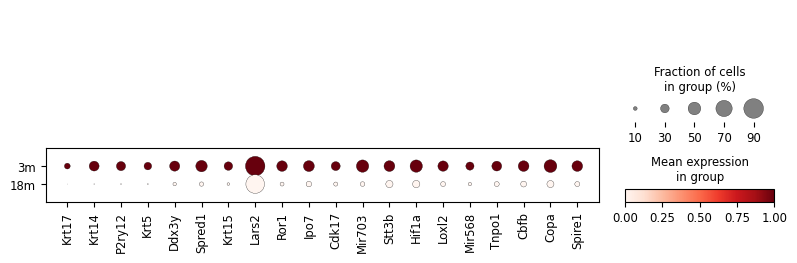

In [6]:
import pandas as pd
sc.tl.rank_genes_groups(
    Skeletal_Muscle_Satellite_Cells,
    groupby='age',
    groups=['18m'],
    reference='3m',
    method='wilcoxon',
    use_raw=False
)
result = Skeletal_Muscle_Satellite_Cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.5) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 1e-5].sort_values(by='18m_l', ascending=False).reset_index(drop=True)
print("Top Upregulated Skeletal Muscle Satellite Cell Drivers (Ranked by Fold Change):")
print(final_up_df[['18m_n', '18m_l', '18m_p']].head(20))
top_genes = final_up_df['18m_n'].head(20).tolist()
subset = Skeletal_Muscle_Satellite_Cells[Skeletal_Muscle_Satellite_Cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

downregulated_genes = dataframe[
    (dataframe['18m_l'] < -0.5) &
    (dataframe['18m_l'] > -15) &
    (dataframe['18m_l'] != float('-inf'))
]
final_down_df = downregulated_genes[downregulated_genes['18m_p'] < 1e-5].sort_values(by='18m_l', ascending=True).reset_index(drop=True)
print("Top Downregulated Skeletal Muscle Satellite Cell Targets (Ranked by Fold Change):")
print(final_down_df[['18m_n', '18m_l', '18m_p']].head(20))
top_down_genes = final_down_df['18m_n'].head(20).tolist()
subset = Skeletal_Muscle_Satellite_Cells[Skeletal_Muscle_Satellite_Cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_down_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

Top 10 Upregulated Pathways in Aged Skeletal Muscle Satellite Cells:
                                                Term  Adjusted P-value Overlap
0           Superoxide Anion Generation (GO:0042554)          0.000028    5/19
1         Defense Response to Bacterium (GO:0042742)          0.000071  10/221
2          Superoxide Metabolic Process (GO:0006801)          0.000320    5/37
3  Negative Regulation of Programmed Cell Death (...          0.000733  11/382
4                 Leukocyte Aggregation (GO:0070486)          0.000739     3/7
5                  Neutrophil Migration (GO:1990266)          0.000739    5/50
6   Hydrogen Peroxide Metabolic Process (GO:0042743)          0.001390    4/28
7          Leukocyte Cell-Cell Adhesion (GO:0007159)          0.001848    4/31
8                          Phagocytosis (GO:0006909)          0.002788    5/71
9            Defense Response to Fungus (GO:0050832)          0.005042    4/42


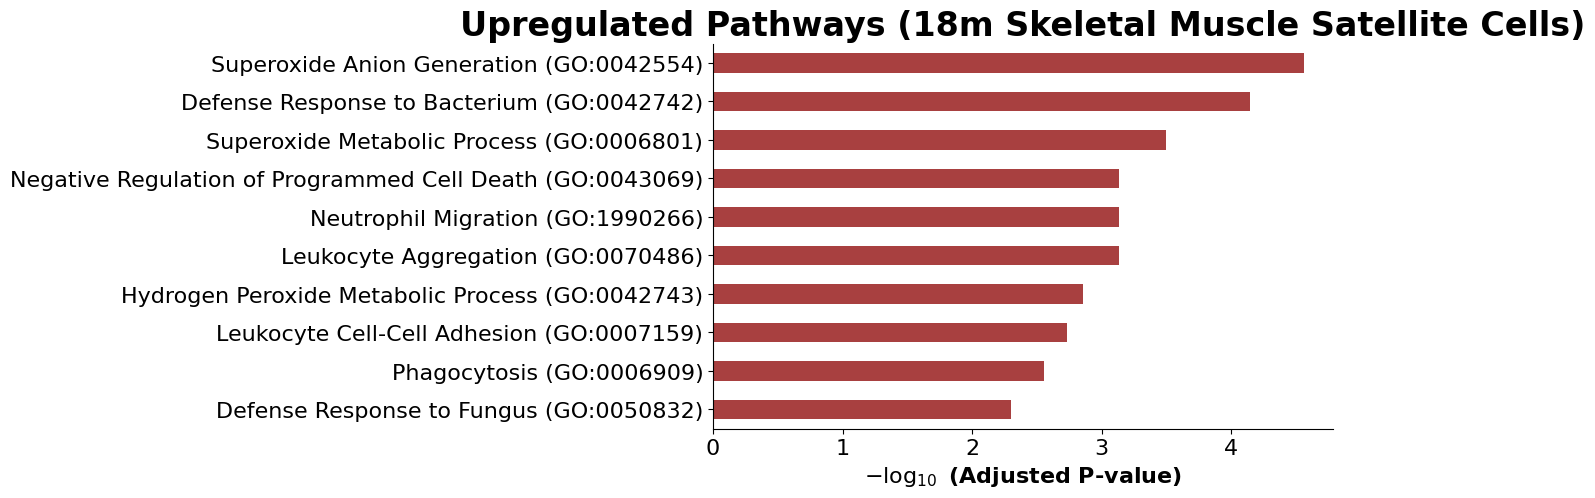

In [8]:
!pip install gseapy
import gseapy as gp
import matplotlib.pyplot as plt
clean_up_genes = final_up_df['18m_n'].head(100).tolist()
enr_up = gp.enrichr(
    gene_list=clean_up_genes,
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
results_up_df = enr_up.results
print("Top 10 Upregulated Pathways in Aged Skeletal Muscle Satellite Cells:")
print(results_up_df[['Term', 'Adjusted P-value', 'Overlap']].head(10))
gp.barplot(
    enr_up.results,
    column="Adjusted P-value",
    title='Upregulated Pathways (18m Skeletal Muscle Satellite Cells)',
    top_term=10,
    figsize=(8, 5),
    color='darkred'
)
plt.show()